In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [18]:
df = pd.read_csv('../resources/ds_salaries_clean.csv')

In [19]:
df.head()

,Working_Year,Designation,Experience,Employment_Status,Employee_Location,Company_Size,Remote_Working_Ratio,Salary_USD
0,2020,Data Scientist,Mid,FT,DE,L,0,76227.0
1,2020,Machine Learning Scientist,Senior,FT,JP,S,0,248257.0
2,2020,Big Data Engineer,Senior,FT,GB,M,50,104100.0
3,2020,Product Data Analyst,Mid,FT,HN,S,0,19097.0
4,2020,Machine Learning Engineer,Senior,FT,US,L,50,143225.0


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Working_Year          607 non-null    int64  
 1   Designation           607 non-null    str    
 2   Experience            607 non-null    str    
 3   Employment_Status     607 non-null    str    
 4   Employee_Location     607 non-null    str    
 5   Company_Size          607 non-null    str    
 6   Remote_Working_Ratio  607 non-null    int64  
 7   Salary_USD            607 non-null    float64
dtypes: float64(1), int64(2), str(5)
memory usage: 53.6 KB


In [21]:
sns.boxplot(
    x='experience_level',
    y='salary_in_usd',
    data=df,
    hue="experience_level"
)

ValueError: Could not interpret value `experience_level` for `x`. An entry with this name does not appear in `data`.

In [22]:
df.isnull().sum()

Working_Year            0
Designation             0
Experience              0
Employment_Status       0
Employee_Location       0
Company_Size            0
Remote_Working_Ratio    0
Salary_USD              0
dtype: int64

# Stratergies for addressing missing data

## Drop missing values
    - 5% or less of total values

## Impute mean , median , mode
    - Depends on distribution and context

## Impute by sub-group
    - Different experience levels have different mean salary
    

# Drop missing values

In [23]:
threshold = len(df) * 0.5
print(threshold)
cols_to_drop = df.columns[df.isna().sum() <= threshold]
print(cols_to_drop)

303.5
Index(['Working_Year', 'Designation', 'Experience', 'Employment_Status',
       'Employee_Location', 'Company_Size', 'Remote_Working_Ratio',
       'Salary_USD'],
      dtype='str')


In [24]:
df.dropna(subset=cols_to_drop,inplace=True)

In [25]:
cols_with_missing_values = df.columns[df.isna().sum() > 0]
print(cols_with_missing_values)

Index([], dtype='str')


In [26]:
for col in cols_with_missing_values[:-1]:
    df[col].fillna(df[col].mode()[0])

# Imputing by sub group

In [27]:

salaries_dict = df.groupby("experience_level")['salary_in_usd'].median().to_dict()
print(salaries_dict)

KeyError: 'experience_level'

In [28]:
df['salary_in_usd'] = df['salary_in_usd'].fillna(df['experience_level'].map(salaries_dict))

KeyError: 'salary_in_usd'

# Converting and analyzing categorical data

In [ ]:
print(df.select_dtypes("object").head())

  experience_level employment_type       job_title salary_currency  \
0               EX              FT    Head of Data             USD   
1               EX              FT    Head of Data             USD   
2               SE              FT  Data Scientist             USD   
3               SE              FT  Data Scientist             USD   
4               MI              FT        Engineer             USD   

  employee_residence company_location company_size  
0                 US               US            M  
1                 US               US            M  
2                 US               US            M  
3                 US               US            M  
4                 US               US            M  


C:\Users\Administrator\AppData\Local\Temp\ipykernel_21092\3335586606.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes("object").head())


In [29]:
print(df['Designation'].value_counts())

Designation
Data Scientist                              143
Data Engineer                               132
Data Analyst                                 97
Machine Learning Engineer                    41
Research Scientist                           16
Data Science Manager                         12
Data Architect                               11
Machine Learning Scientist                    8
Big Data Engineer                             8
Data Science Consultant                       7
Director of Data Science                      7
AI Scientist                                  7
Principal Data Scientist                      7
Data Analytics Manager                        7
Lead Data Engineer                            6
BI Data Analyst                               6
ML Engineer                                   6
Computer Vision Engineer                      6
Business Data Analyst                         5
Data Engineering Manager                      5
Head of Data                

# find unique values in a dataset

In [30]:
print(df['Designation'].nunique())

50


# Extracting value from categories

In [31]:
df['Designation'].str.contains("Scientist")

0       True
1       True
2      False
3      False
4      False
       ...  
602    False
603    False
604    False
605    False
606     True
Name: Designation, Length: 607, dtype: bool

# Finding multiple words

In [32]:
df['Designation'].str.contains("Machine Learning|AI")

0      False
1       True
2      False
3      False
4       True
       ...  
602    False
603    False
604    False
605    False
606     True
Name: Designation, Length: 607, dtype: bool

# Finding multiple phrases in strings
- Word of intrest : Any that start with data

In [33]:
df['Designation'].str.contains('^Data')

0       True
1      False
2      False
3      False
4      False
       ...  
602     True
603     True
604     True
605     True
606    False
Name: Designation, Length: 607, dtype: bool

In [34]:
job_categories = ['Data Science','Data Analytics','Data Engineering','Machine Learning','Managerial','Consultant']


data_science = "Data Scientist|NLP"
data_analyst = "Analyst|Analytics"
data_engineer = "Data Engineer|ETLArchitect|Infrastructure"
ml_engineer = "Machine Learning|ML|Big Data|AI"
manager = "Manager|Head|Director|Lead|Principal|Staff"
consultant = "Consultant|Freelance"

In [35]:

conditions = [
(df["Designation"].str.contains(data_science)),
(df["Designation"].str.contains(data_analyst)),
(df["Designation"].str.contains(data_engineer)),
(df["Designation"].str.contains(ml_engineer)),
(df["Designation"].str.contains(manager)),
(df["Designation"].str.contains(consultant))
]

df['Job_Category'] = np.select(
    conditions,
    job_categories,
    default='Other'
)

In [36]:
print(df[['Designation','Job_Category']].head())

                  Designation      Job_Category
0              Data Scientist      Data Science
1  Machine Learning Scientist  Machine Learning
2           Big Data Engineer  Data Engineering
3        Product Data Analyst    Data Analytics
4   Machine Learning Engineer  Machine Learning


<Axes: xlabel='Job_Category', ylabel='count'>

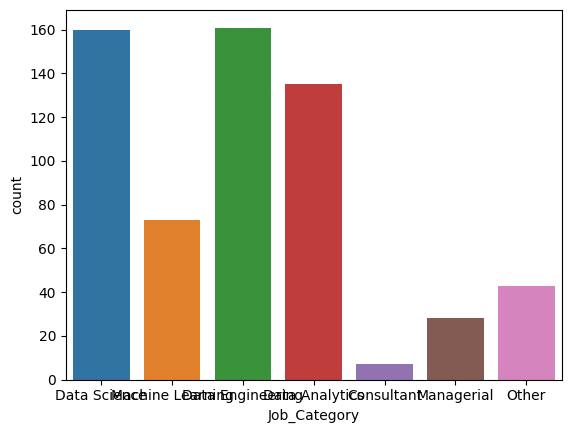

In [37]:
sns.countplot(data=df,x='Job_Category',hue='Job_Category')

# Coverting strings to numbers

In [38]:
pd.Series.str.replace('char to remove','char to replace')

AttributeError: 'str' object has no attribute '_inferred_dtype'

In [39]:
df.groupby('Company_Size')['Salary_USD'].mean()

Company_Size
L    113857.282828
M    111625.328221
S     74126.313253
Name: Salary_USD, dtype: float64

In [40]:
df['std_dev'] = df.groupby('Experience')['Salary_USD'].transform(lambda x : x.std())

In [41]:
print(df[['Experience','std_dev']].value_counts())

Experience  std_dev      
Senior      55086.264071     280
Mid         61014.876754     213
Entry       42390.355189      88
Executive   111783.576779     26
Name: count, dtype: int64


In [43]:
df['median_by_comp_size'] = df.groupby("Company_Size")["Salary_USD"].transform(lambda x : x.median())

In [44]:
print(df[['Company_Size','median_by_comp_size']].head())

  Company_Size  median_by_comp_size
0            L              95483.0
1            S              62064.0
2            M             108076.0
3            S              62064.0
4            L              95483.0


# Handling Outliers

- Using descriptive stats

In [45]:
print(df['Salary_USD'].describe())

count       607.000000
mean     107225.836903
std       67752.393254
min        2730.000000
25%       59893.000000
50%       96982.000000
75%      143225.000000
max      572900.000000
Name: Salary_USD, dtype: float64


# Interquartile Range

<Axes: ylabel='Salary_USD'>

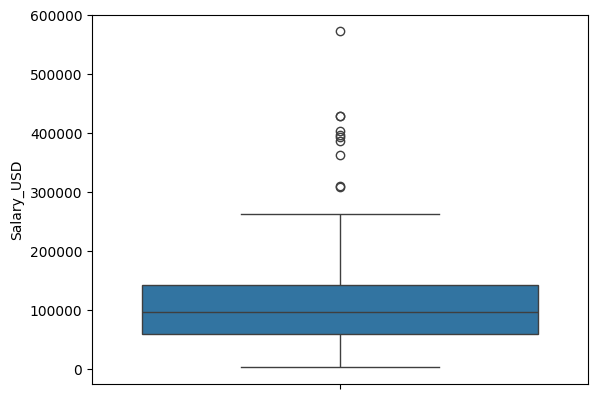

In [46]:
sns.boxplot(
    data=df,
    y='Salary_USD'
)

In [55]:
seventy_fifth = df['Salary_USD'].quantile(0.75)
twenty_fifth = df['Salary_USD'].quantile(0.25)

IQR = seventy_fifth - twenty_fifth

print(IQR)

83332.0


In [56]:
upper = seventy_fifth + (1.5 * IQR)
lower = twenty_fifth - (1.5 * IQR)

print(upper,lower)

268223.0 -65105.0


In [57]:

df[(df["Salary_USD" ] < lower) | (df["Salary_USD"] > upper)][["Experience", "Employee_Location", "Salary_USD" ]]

,Experience,Employee_Location,Salary_USD
25,Executive,US,310321.0
33,Mid,US,429675.0
63,Senior,US,393392.0
97,Mid,US,429675.0
157,Mid,US,403895.0
225,Executive,US,397211.0
252,Executive,US,572900.0
482,Executive,US,309366.0
519,Senior,US,362837.0
523,Senior,US,386708.0


In [60]:
no_outliers = df[(df["Salary_USD" ] > lower) & (df["Salary_USD"] < upper)]
print(no_outliers['Salary_USD'].describe())

count       597.000000
mean     102328.480737
std       55910.790653
min        2730.000000
25%       59819.000000
50%       95483.000000
75%      141565.000000
max      263534.000000
Name: Salary_USD, dtype: float64


<Axes: xlabel='Salary_USD', ylabel='Count'>

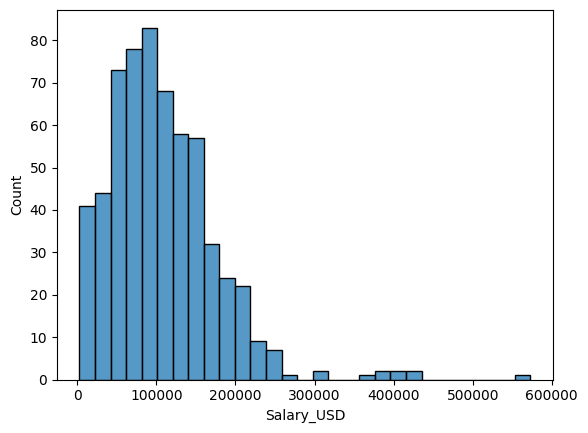

In [61]:
sns.histplot(
    x='Salary_USD',
    data=df
)

<Axes: xlabel='Salary_USD', ylabel='Count'>

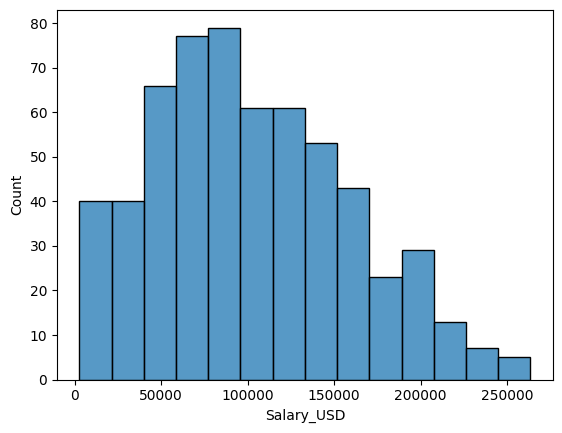

In [62]:
sns.histplot(
    x='Salary_USD',
    data=no_outliers
)